# SHAP — módulo 05

Valores de Shapley e SHAP — Molnar, *Interpretable Machine Learning*,
caps. 17–18; Lundberg & Lee (2017); Lundberg et al. (2020, TreeSHAP) —
sobre **o modelo do curso** (módulo 00). Módulo novo, sem versão BCW.

A espinha é o **TreeSHAP exato que já mora no XGBoost**:
`pred_contribs=True` devolve, para cada predição, 40 contribuições + base
que **somam a margem exatamente** — não é amostrado, não é aproximado.

A biblioteca `shap` não é usada, e a decisão está registrada: no stack
pinado (numpy 2.x, Python 3.12), a resolução dela exige um par
numba/llvmlite que não constrói neste ambiente (medido no PR do pin, com
o critério de falsificação "o diff do lock só pode ter adições"). O que
se perde com isso — os gráficos prontos e o KernelSHAP — este notebook
refaz no que importa; o que não se perde é o algoritmo, que é o mesmo.

In [1]:
%pip install -q lime xgboost scikit-learn scipy matplotlib numpy pandas pyarrow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pathlib
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgblib
from scipy.special import expit

pd.set_option("display.width", 120)
RANDOM_STATE = 42

REPO = pathlib.Path.cwd()
while REPO != REPO.parent and not (REPO / "tools" / "srag_model.py").exists():
    REPO = REPO.parent
if not (REPO / "tools" / "srag_model.py").exists():
    import tempfile
    REPO = pathlib.Path(tempfile.gettempdir()) / "interpretable-ml-lectures"
    if not REPO.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/wbendinelli/interpretable-ml-lectures.git",
                        str(REPO)], check=True)
sys.path.insert(0, str(REPO / "tools"))
import srag_model as M

FIGDIR = pathlib.Path("figures_generated")
FIGDIR.mkdir(exist_ok=True)

g = M.load_gold(REPO / "modules/00-dataset/gold/gold_covid_obito_sample.parquet")
xgb, _logit = M.fit_models(g)
paciente = M.pick_exemplar(xgb, g)
booster = xgb.get_booster()


def dmatrix(frame):
    x, _, _ = frame_x = M.design_matrix(frame)
    return xgblib.DMatrix(x, enable_categorical=True)


teste = g[g["split"] == "test"].reset_index(drop=True)
dm_teste = dmatrix(teste)
contrib = booster.predict(dm_teste, pred_contribs=True)
margem = booster.predict(dm_teste, output_margin=True)
NOMES = list(M.FEATURES) + ["base"]

desvio = float(np.abs(contrib.sum(axis=1) - margem).max())
print(f"contribuições no teste: {contrib.shape[0]:,} × {contrib.shape[1]} "
      f"(40 features + base)".replace(",", "."))
print(f"aditividade exata: |soma das contribuições − margem| máximo = {desvio:.2e}")
print(f"base value (margem): {contrib[0, -1]:.4f} — "
      f"sigmoide dá {expit(contrib[0, -1]):.4f}")

contribuições no teste: 16.142 × 41 (40 features + base)
aditividade exata: |soma das contribuições − margem| máximo = 7.63e-06
base value (margem): -0.7919 — sigmoide dá 0.3118


## §1 — A atribuição que soma, exatamente

O LIME (módulo 03) ajusta um substituto e reporta R²; a soma dos pesos
não tem compromisso com a predição. A contribuição de Shapley tem a
**eficiência** por axioma: as 40 parcelas + base somam a margem, e a
sigmoide da soma é a probabilidade do paciente — dígito por dígito.

As contribuições vivem na **margem** (log-odds), não na probabilidade:
é o espaço em que somar faz sentido para uma floresta de árvores.

paciente-regra gold_id 1269214:
  soma das 40 contribuições + base = +0.0000 (margem)
  sigmoide(+0.0000) = 0.5000  |  p do modelo: 0.5000

as 10 maiores contribuições, com o valor do paciente:
  idade_anos                 +0.6689   (valor: 84.40520477294922)
  vacina_covid_declarada     -0.4617   (valor: True)
  neurologic                 +0.3402   (valor: sim)
  meses_desde_mar2020        -0.2412   (valor: 47.20762252807617)
  regiao                     +0.2410   (valor: N)
  cs_sexo                    -0.1513   (valor: feminino)
  diarreia                   -0.1469   (valor: sim)
  saturacao                  +0.1429   (valor: sim)
  out_morbi                  +0.1185   (valor: sim)
  cs_raca                    +0.1041   (valor: branca)


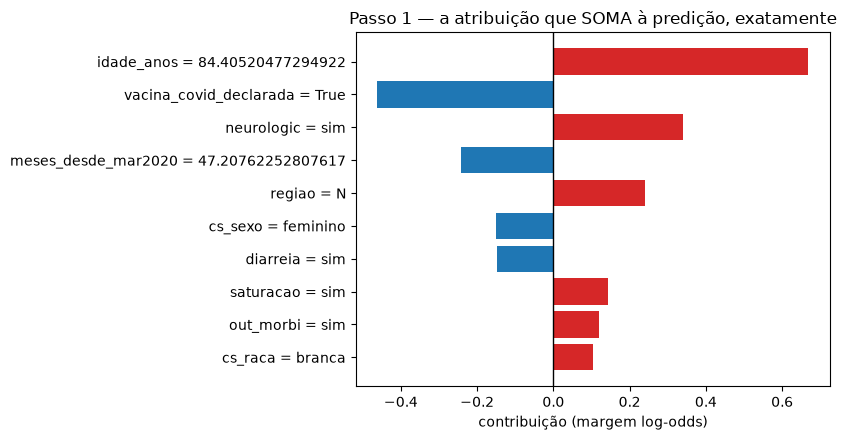

In [3]:
ix = teste.index[teste["gold_id"] == int(paciente["gold_id"])][0]
c_pac = contrib[ix]
soma = float(c_pac.sum())
print(f"paciente-regra gold_id {int(paciente['gold_id'])}:")
print(f"  soma das 40 contribuições + base = {soma:+.4f} (margem)")
print(f"  sigmoide({soma:+.4f}) = {expit(soma):.4f}  |  p do modelo: "
      f"{paciente['p_obito']:.4f}")

o = np.argsort(-np.abs(c_pac[:-1]))[:10]
print("\nas 10 maiores contribuições, com o valor do paciente:")
for j in o:
    print(f"  {NOMES[j]:26s} {c_pac[j]:+.4f}   (valor: {paciente[NOMES[j]]})")

fig, ax = plt.subplots(figsize=(8.5, 4.5))
rotulos = [f"{NOMES[j]} = {paciente[NOMES[j]]}" for j in o][::-1]
vals = [c_pac[j] for j in o][::-1]
ax.barh(rotulos, vals,
        color=["tab:red" if v > 0 else "tab:blue" for v in vals])
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("contribuição (margem log-odds)")
ax.set_title("Passo 1 — a atribuição que SOMA à predição, exatamente")
fig.tight_layout()
fig.savefig(FIGDIR / "shap_passo_1_soma.png", dpi=150, bbox_inches="tight")
plt.show()

## §2 — SHAP × LIME, no mesmo paciente

Os dois métodos locais do curso, lado a lado, no paciente-regra. Escalas
diferentes por construção (margem exata vs peso de reta em nuvem
padronizada) — o que pode e deve bater é a **direção**.

feature                     SHAP (margem)   LIME (peso)   sinais
idade_anos                       +0.6689      +0.1198   concordam
vacina_covid_declarada           -0.4617      -0.1888   concordam
neurologic                       +0.3402      +0.0714   concordam
meses_desde_mar2020              -0.2412      +0.0132   DIVERGEM
regiao                           +0.2410      +0.0518   concordam
cs_sexo                          -0.1513      -0.0414   concordam
diarreia                         -0.1469      -0.0077   concordam
saturacao                        +0.1429      +0.0749   concordam

concordância de sinal no top-8 SHAP: 7/8


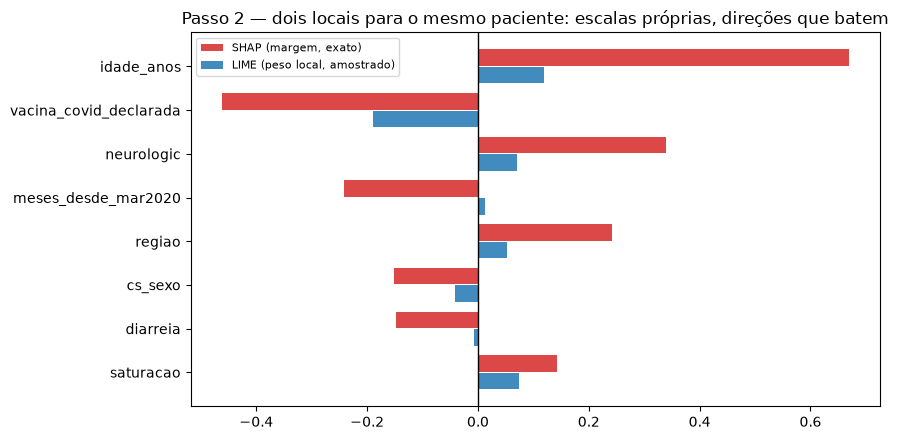

In [4]:
from lime.lime_tabular import LimeTabularExplainer

train = g[g["split"] == "train"].reset_index(drop=True)
CATS = {c: g[c].cat.categories for c in M.CATEGORICAS}
ORDEM = list(M.FEATURES)
IDX_CAT = [ORDEM.index(c) for c in M.CATEGORICAS]
IDX_BOOL = [ORDEM.index(c) for c in M.BOOLEANAS]


def para_matriz(df):
    cols = []
    for c in ORDEM:
        if c in M.CATEGORICAS:
            cols.append(df[c].cat.codes.to_numpy(dtype=np.float64))
        else:
            cols.append(df[c].to_numpy(dtype=np.float64))
    return np.column_stack(cols)


def reconstruir(arr):
    df = pd.DataFrame(np.asarray(arr, dtype=np.float64), columns=ORDEM)
    for c in M.CATEGORICAS:
        cod = np.clip(np.rint(df[c].to_numpy()), 0, len(CATS[c]) - 1).astype(int)
        df[c] = pd.Categorical.from_codes(cod, categories=CATS[c])
    for c in M.BOOLEANAS:
        df[c] = df[c] >= 0.5
    return df


def predict_fn(arr):
    df = reconstruir(arr).assign(y_obito=0, split="test")
    x, _, _ = M.design_matrix(df)
    return xgb.predict_proba(x)


X_train = para_matriz(train)
x_pac = para_matriz(pd.DataFrame([paciente[ORDEM]]).astype(train[ORDEM].dtypes))[0]
exp = LimeTabularExplainer(
    X_train, mode="classification", feature_names=ORDEM,
    categorical_features=IDX_CAT + IDX_BOOL,
    categorical_names={ORDEM.index(c): list(CATS[c]) for c in M.CATEGORICAS},
    discretize_continuous=False, random_state=RANDOM_STATE)
e = exp.explain_instance(x_pac, predict_fn, num_features=40, num_samples=5000)
pesos_lime = {}
for f, w in e.as_list():
    pesos_lime[f.split("=")[0].strip()] = w

top8 = [NOMES[j] for j in np.argsort(-np.abs(c_pac[:-1]))[:8]]
print("feature                     SHAP (margem)   LIME (peso)   sinais")
iguais = 0
for c in top8:
    s = float(c_pac[NOMES.index(c)])
    w = pesos_lime.get(c, 0.0)
    ok = np.sign(s) == np.sign(w)
    iguais += int(ok)
    print(f"{c:26s} {s:+13.4f} {w:+12.4f}   {'concordam' if ok else 'DIVERGEM'}")
print(f"\nconcordância de sinal no top-8 SHAP: {iguais}/8")

fig, ax = plt.subplots(figsize=(9, 4.5))
ys = np.arange(len(top8))[::-1]
shap_v = [float(c_pac[NOMES.index(c)]) for c in top8]
lime_v = [pesos_lime.get(c, 0.0) for c in top8]
ax.barh(ys + 0.2, shap_v, height=0.38, color="tab:red", alpha=0.85,
        label="SHAP (margem, exato)")
ax.barh(ys - 0.2, lime_v, height=0.38, color="tab:blue", alpha=0.85,
        label="LIME (peso local, amostrado)")
ax.set_yticks(ys, top8)
ax.axvline(0, color="black", lw=1)
ax.set_title("Passo 2 — dois locais para o mesmo paciente: escalas próprias, direções que batem")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGDIR / "shap_passo_2_vs_lime.png", dpi=150, bbox_inches="tight")
plt.show()

## §3 — O retrato global

Média de |contribuição| no teste — a importância "para as predições
de 2024" — contra o `gain` do treino, a importância "para a construção
das árvores". Os postos não coincidem, e não têm por quê: uma feature
pode ter comprado muitas divisões em 2020–2022 e importar pouco no
regime de 2024 (módulo 02 mediu essa deriva por outro ângulo).

top-10 global por média|SHAP| no teste, contra o gain do treino:
feature                     média|SHAP|   gain   posto(gain)
idade_anos                      0.9192   89.5   1
vacina_covid_declarada          0.3771   50.6   2
meses_desde_mar2020             0.3049   15.9   16
saturacao                       0.2171   29.6   7
regiao                          0.1501   14.7   18
out_morbi                       0.1294   29.4   8
n_doses_antes_do_sintoma        0.1281   24.3   11
desc_resp                       0.1267   31.0   6
dispneia                        0.1247   34.4   5
semana_epi                      0.1102   13.6   20


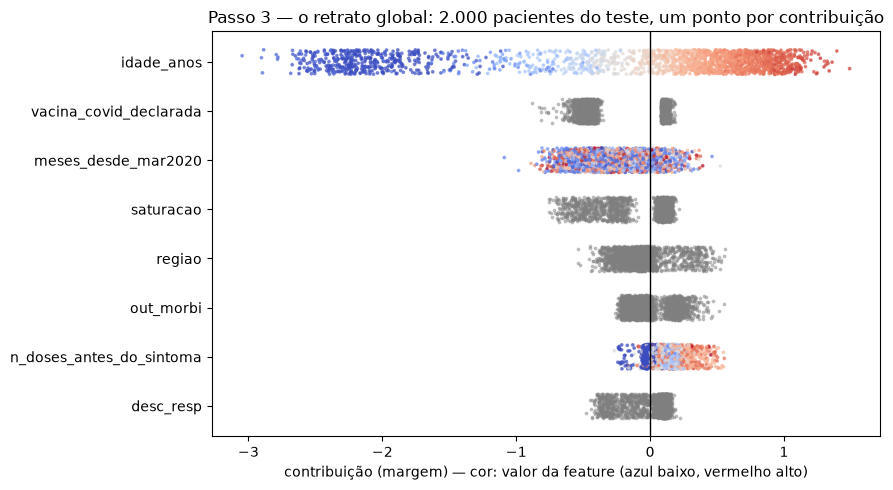

In [5]:
mabs = np.abs(contrib[:, :-1]).mean(axis=0)
og = np.argsort(-mabs)[:10]
gain = booster.get_score(importance_type="gain")
print("top-10 global por média|SHAP| no teste, contra o gain do treino:")
print("feature                     média|SHAP|   gain   posto(gain)")
postos_gain = {c: r + 1 for r, (c, _) in enumerate(
    sorted(gain.items(), key=lambda kv: -kv[1]))}
for j in og:
    c = NOMES[j]
    print(f"{c:26s} {mabs[j]:11.4f} {gain.get(c, 0.0):6.1f}   {postos_gain.get(c, '—')}")

rng = np.random.default_rng(RANDOM_STATE)
sub = rng.choice(len(contrib), size=2000, replace=False)
fig, ax = plt.subplots(figsize=(9, 5))
top8g = og[:8]
for linha_y, j in enumerate(top8g[::-1]):
    xs = contrib[sub, j]
    c = NOMES[j]
    if c in M.NUMERICAS:
        v = teste[c].to_numpy(dtype=float)[sub]
        cor = (v - v.min()) / (v.max() - v.min() + 1e-9)
        ax.scatter(xs, linha_y + rng.uniform(-0.25, 0.25, len(xs)), s=3,
                   c=cor, cmap="coolwarm", alpha=0.6)
    else:
        ax.scatter(xs, linha_y + rng.uniform(-0.25, 0.25, len(xs)), s=3,
                   color="tab:gray", alpha=0.4)
ax.set_yticks(range(len(top8g)), [NOMES[j] for j in top8g[::-1]])
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("contribuição (margem) — cor: valor da feature (azul baixo, vermelho alto)")
ax.set_title("Passo 3 — o retrato global: 2.000 pacientes do teste, um ponto por contribuição")
fig.tight_layout()
fig.savefig(FIGDIR / "shap_passo_3_global.png", dpi=150, bbox_inches="tight")
plt.show()

## §4 — Caminho × intervenção

`pred_contribs` usa o algoritmo *path-dependent* de Lundberg: as
coalizões "ausentes" são preenchidas seguindo as frequências dos caminhos
da própria árvore — o condicionamento herda as correlações do treino. A
alternativa *interventional* quebra as correlações de propósito:
substitui os ausentes por valores de um fundo real e mede o efeito da
troca. Sem a lib, o interventional sai na mão — Shapley por amostragem de
permutações, no mesmo espaço de margem. A diferença entre as duas colunas
mistura o preço do condicionamento com ruído de Monte Carlo; os internals
(§4) separam os dois.

Shapley por permutação (interventional): 60 permutações × fundo de 200 — 2.460 linhas avaliadas

feature                     pred_contribs   permutação   diferença
idade_anos                       +0.6689      +0.7813     +0.1123
vacina_covid_declarada           -0.4617      -0.6349     -0.1732
neurologic                       +0.3402      +0.3567     +0.0165
meses_desde_mar2020              -0.2412      -0.2663     -0.0251
regiao                           +0.2410      +0.3092     +0.0682
cs_sexo                          -0.1513      -0.1138     +0.0376
diarreia                         -0.1469      -0.1477     -0.0007
saturacao                        +0.1429      +0.1788     +0.0359


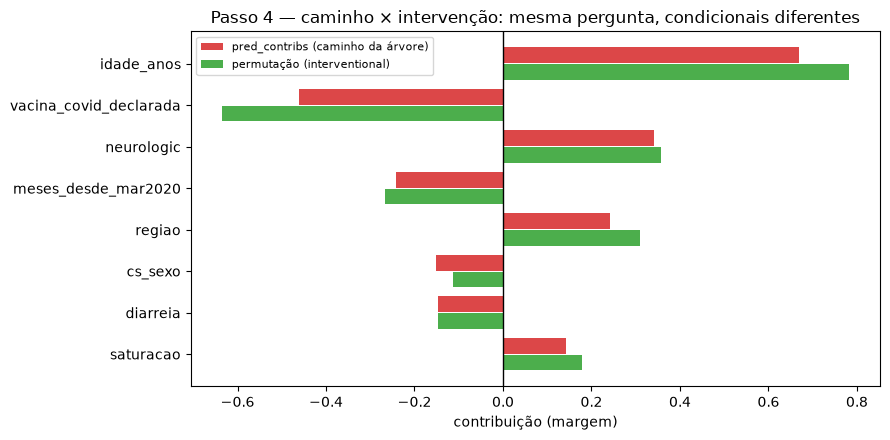

In [6]:
train_pool = g[g["split"] == "train"].reset_index(drop=True)
fundo = train_pool.sample(200, random_state=RANDOM_STATE).reset_index(drop=True)
rng = np.random.default_rng(RANDOM_STATE)
N_PERM = 60

phi = {c: 0.0 for c in M.FEATURES}
hibridos = []
for t in range(N_PERM):
    bg = fundo.iloc[int(rng.integers(len(fundo)))]
    ordem_f = list(rng.permutation(M.FEATURES))
    linha = {c: bg[c] for c in g.columns}
    linhas = [dict(linha)]
    for c in ordem_f:
        linha[c] = paciente[c]
        linhas.append(dict(linha))
    frame = pd.DataFrame(linhas).astype(g.dtypes)
    hibridos.append(frame)
    m = booster.predict(dmatrix(frame), output_margin=True)
    for k, c in enumerate(ordem_f):
        phi[c] += float(m[k + 1] - m[k]) / N_PERM

print(f"Shapley por permutação (interventional): {N_PERM} permutações × fundo "
      f"de {len(fundo)} — {N_PERM * (len(M.FEATURES) + 1):,} linhas avaliadas"
      .replace(",", "."))
top8 = [NOMES[j] for j in np.argsort(-np.abs(c_pac[:-1]))[:8]]
print("\nfeature                     pred_contribs   permutação   diferença")
for c in top8:
    s = float(c_pac[NOMES.index(c)])
    p_i = phi[c]
    print(f"{c:26s} {s:+13.4f} {p_i:+12.4f} {p_i - s:+11.4f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ys = np.arange(len(top8))[::-1]
ax.barh(ys + 0.2, [float(c_pac[NOMES.index(c)]) for c in top8], height=0.38,
        color="tab:red", alpha=0.85, label="pred_contribs (caminho da árvore)")
ax.barh(ys - 0.2, [phi[c] for c in top8], height=0.38,
        color="tab:green", alpha=0.85, label="permutação (interventional)")
ax.set_yticks(ys, top8)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("contribuição (margem)")
ax.set_title("Passo 4 — caminho × intervenção: mesma pergunta, condicionais diferentes")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGDIR / "shap_passo_4_interventional.png", dpi=150, bbox_inches="tight")
plt.show()

## §5 — As coalizões são Frankensteins

O interventional avalia o modelo em **híbridos**: features do paciente
enxertadas em pacientes de fundo. O curso inteiro perguntou "quem são as
linhas que o método entrega ao modelo?" — a mesma régua
(`gate_impossible`, contexto do paciente de fundo, que é real) fecha o
arco no último método.

In [7]:
todos = pd.concat(hibridos, ignore_index=True)
imp = M.gate_impossible(todos)
comorb = M.CATEGORICAS[5:18]
alguma = pd.concat([(todos[c].astype(str) == "sim") for c in comorb],
                   axis=1).any(axis=1)
portao = (alguma & ~todos["fator_risc_portao"].astype(bool)).mean()
pre = ((todos["meses_desde_mar2020"] < M.MESES_CAMPANHA)
       & (todos["n_doses_antes_do_sintoma"] > 0)).mean()
n2 = sum((todos[c].astype(str) == "sim").astype(int) for c in ("tosse", "garganta"))
n3 = sum((todos[c].astype(str) == "sim").astype(int)
         for c in ("dispneia", "saturacao", "desc_resp"))
fora = ((n2 < 1) | (n3 < 1)).mean()
print(f"linhas híbridas avaliadas pela permutação: {len(todos):,}".replace(",", "."))
print(f"impossíveis pela gate_impossible: {100 * imp.mean():.2f}%")
print(f"  portão {100 * portao:.2f}% | dose pré-campanha {100 * pre:.2f}% | "
      f"fora da coorte {100 * fora:.2f}%")
print()
print("o contexto de cada híbrido é o do paciente de fundo (o fator_risc_portao")
print("dele é um valor real registrado); o enxerto das features do paciente-alvo")
print("em cima é que fabrica as contradições — coalizões são Frankensteins.")

linhas híbridas avaliadas pela permutação: 2.460
impossíveis pela gate_impossible: 26.34%
  portão 19.15% | dose pré-campanha 8.17% | fora da coorte 0.00%

o contexto de cada híbrido é o do paciente de fundo (o fator_risc_portao
dele é um valor real registrado); o enxerto das features do paciente-alvo
em cima é que fabrica as contradições — coalizões são Frankensteins.


## O que carregar — e o fechamento do curso

1. TreeSHAP nativo dá atribuição **exata e determinística** ao custo de
   uma predição — quando o modelo é árvore, é o ponto de partida certo.
2. A exatidão é sobre a **soma**, não sobre a semântica: caminho ×
   intervenção respondem condicionais diferentes e divergem onde as
   features se correlacionam (meses × doses, de novo).
3. O interventional compra a leitura causal-ish avaliando o modelo em
   Frankensteins — mensuráveis pela mesma cerca dos outros módulos.

| módulo | pergunta | quem o método entrega ao modelo |
|---|---|---|
| 01 CP | e se mudar UMA coisa? | o paciente, com um campo torcido |
| 02 ICE | isso, para todo mundo? | 200 pacientes torcidos em fila |
| 03 LIME | que reta explica a vizinhança? | uma nuvem sem dono |
| 04 CF | o que mudaria a decisão? | candidatos de busca — e a lista de alavancas decide |
| 05 SHAP | quanto cada campo contribuiu? | coalizões — caminhos da árvore ou Frankensteins |

A pergunta que sobrevive aos cinco: **quem são as linhas** — e a resposta
sempre coube na mesma função de dez linhas que este curso escreveu uma
vez e usou cinco vezes.